In [1]:
import xarray as xr
import rioxarray as rxr
from rioxarray.merge import merge_arrays
import numpy as np
import matplotlib.pyplot as plt
import geopandas as gpd
from pathlib import Path
import scipy
from scipy.ndimage import gaussian_filter1d

/hpc/home/acd99/.local/lib/python3.11/site-packages/pandas/core/computation/expressions.py:23: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.7' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/hpc/home/acd99/.local/lib/python3.11/site-packages/pandas/core/arrays/masked.py:56: UserWarning: Pandas requires version '1.4.2' or newer of 'bottleneck' (version '1.3.7' currently installed).
  from pandas.core import (


In [2]:
# load data
ds = xr.open_dataset('ncqs_total_hourly_pertransect.nc')
ds = ds.sum(dim='time') * 3600

In [4]:
# smooth data
sigma = 50  # smoothing window, in units of points

qs_smooth = gaussian_filter1d(ds['qs'].values, sigma=sigma, mode='nearest')

ds = ds.assign(
    qs_smooth=("site", qs_smooth),
)

In [12]:
def get_dists_xr(ds):
    
    ''' Computes distance between adjacent points '''
    
    lat = np.radians(ds['lat'])
    lon = np.radians(ds['lon'])

    lat1 = lat.shift(site=1)
    lon1 = lon.shift(site=1)
    lat2 = lat.shift(site=-1)
    lon2 = lon.shift(site=-1)

    R = 6371000.0 # earth radius in meters
    
    phi1 = lat1
    phi2 = lat2
    delta_phi = lat2 - lat1
    delta_lambda = lon2 - lon1
    
    # haversine calculation
    a = np.sin(delta_phi / 2)**2 + np.cos(phi1) * np.cos(phi2) * np.sin(delta_lambda / 2)**2
    c = 2 * np.arctan2(np.sqrt(a), np.sqrt(1 - a))
    
    distance = R * c

    return distance

In [22]:
def get_delta_qs(ds):

    ''' Calculates change in Qs between points '''

    qs = ds['qs_smooth']

    qs1 = qs.shift(site=1)
    qs2 = qs.shift(site=-1)

    dqs = qs1-qs2

    return dqs

In [23]:
dists_xr = get_dists_xr(ds)
dqs_xr = get_delta_qs(ds)
grad = dqs_xr/dists_xr

In [24]:
# perpare landsat mosaic
IMG_DIR = Path("imagery")

red_files = [IMG_DIR / f for f in [
    'LC08_L2SP_014035_20170409_20200904_02_T1_SR_B4.TIF',
    'LC08_L2SP_014036_20170409_20200904_02_T1_SR_B4.TIF',
    'LC08_L2SP_015036_20170502_20200904_02_T1_SR_B4.TIF',
    'LC08_L2SP_014036_20170527_20200903_02_T1_SR_B4.TIF',
]]

green_files = [IMG_DIR / f for f in [
    'LC08_L2SP_014035_20170409_20200904_02_T1_SR_B3.TIF',
    'LC08_L2SP_014035_20170409_20200904_02_T1_SR_B3.TIF',
    'LC08_L2SP_015036_20170502_20200904_02_T1_SR_B3.TIF',
    'LC08_L2SP_014036_20170527_20200903_02_T1_SR_B3.TIF',
]]

blue_files = [IMG_DIR / f for f in [
    'LC08_L2SP_014035_20170409_20200904_02_T1_SR_B2.TIF',
    'LC08_L2SP_014036_20170409_20200904_02_T1_SR_B2.TIF',
    'LC08_L2SP_015036_20170502_20200904_02_T1_SR_B2.TIF',
    'LC08_L2SP_014036_20170527_20200903_02_T1_SR_B2.TIF',
]]

def mosaic_band(file_list):
    """Opens a list of TIFs and merges them into one array."""
    elements = [rxr.open_rasterio(f, masked=True).squeeze() for f in file_list]
    return merge_arrays(elements)

print("Mosaicking bands... ")
merged_red = mosaic_band(red_files)
merged_green = mosaic_band(green_files)
merged_blue = mosaic_band(blue_files)

rgb = xr.concat([merged_red, merged_green, merged_blue], dim='band')
rgb['band'] = [1, 2, 3]

rgb_scaled = (rgb / 20000).clip(0, 1)
print('Done! :)')

Mosaicking bands... 
Done! :)


/opt/apps/rhel9/Anaconda3-2024.02/lib/python3.11/site-packages/matplotlib/cm.py:489: RuntimeWarning: invalid value encountered in cast
  xx = (xx * 255).astype(np.uint8)


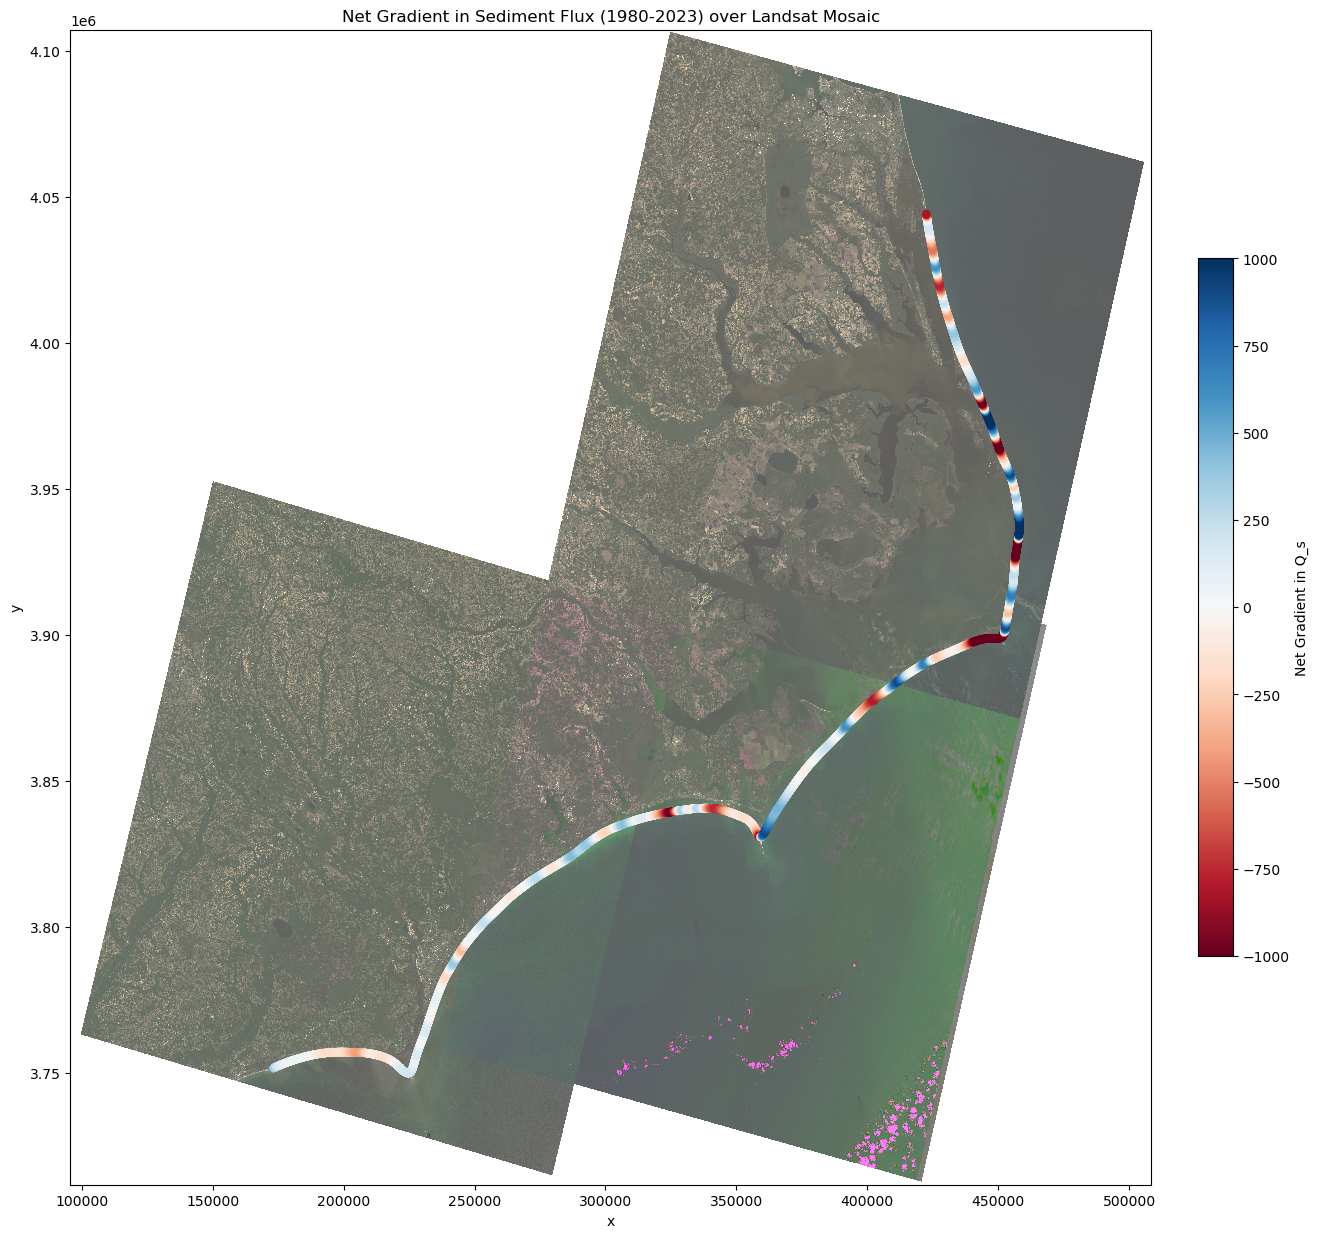

In [25]:
lon = grad['lon']
lat = grad['lat']

gdf = gpd.GeoDataFrame(
    {'grad': grad.values},
    geometry=gpd.points_from_xy(lon, lat),
    crs="EPSG:4326"
)
gdf = gdf.to_crs(rgb.rio.crs)

fig, ax = plt.subplots(figsize=(15, 15))

rgb_scaled.plot.imshow(rgb='band', ax=ax)

limit = 1000
scatter = ax.scatter(
    gdf.geometry.x, 
    gdf.geometry.y, 
    c=gdf['grad'],
    vmin=-limit, vmax=limit,
    cmap='RdBu', 
    s=25
)

plt.colorbar(scatter, label='Net Gradient in Q_s', fraction=0.03, pad=0.04)
plt.title(f"Net Gradient in Sediment Flux (1980-2023) over Landsat Mosaic")
# ax.set_axis_off() # hides UTM coordinates
plt.show()